# Práctica 4 · Notebook 01: Medidas de localización
**Dataset:** ENDIREH 2021 · **Framework:** polars

**Pregunta que contesta este notebook:** ¿alrededor de qué valor se agrupan los datos?
Calculamos media, mediana, moda, cuartiles y percentiles, primero **sin ponderar** y luego **ponderando por `factor_expansion`**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# --- Para que el notebook encuentre config/ y src/ (corre desde la carpeta notebooks/ del repo)
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ))

try:
    # Modo repo (VS Code / Jupyter dentro del proyecto)
    from src import descriptivas as d
    try:
        from config import rutas as r
    except ImportError:
        r = None
    ARCHIVO_LIMPIO = getattr(r, "ARCHIVO_LIMPIO", RAIZ / "data" / "data-processed" / "endireh_2021_clean.parquet")
    RUTA_FIGURAS = getattr(r, "RUTA_FIGURAS", RAIZ / "reports" / "figures")
except ImportError:
    # Modo Colab: te pide subir 2 archivos (descriptivas.py y el .parquet)
    ARCHIVO_LIMPIO = Path("endireh_2021_clean.parquet")
    RUTA_FIGURAS = Path("figures")
    if not (Path("descriptivas.py").exists() and ARCHIVO_LIMPIO.exists()):
        from google.colab import files
        print("Sube estos 2 archivos: descriptivas.py y endireh_2021_clean.parquet")
        files.upload()
    sys.path.append(str(Path.cwd()))
    import descriptivas as d

RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
print("Archivo de datos:", ARCHIVO_LIMPIO)

Archivo de datos: C:\Users\super\Documents\AyrosCyrsBack\Practica-3---Polars\data\data-processed\endireh_2021_clean.parquet


## Paso 1. Cargar los datos limpios
Usamos el archivo de `data/data-processed/`. La ruta viene de `config/rutas.py`, no está escrita a mano.

In [2]:
df = pl.read_parquet(ARCHIVO_LIMPIO)
print("Dimensiones:", df.shape)

VARS = ["edad_primer_union", "num_hijos"]   # variables cuantitativas principales
PESO = "factor_expansion"                   # a cuántas mujeres representa cada fila

# Solo quitamos filas con nulos en lo que vamos a usar
df_ok = df.drop_nulls(subset=VARS + [PESO])
print("Filas que usamos:", df_ok.height)
df_ok.select(VARS + [PESO]).describe()

Dimensiones: (105296, 26)
Filas que usamos: 105296


statistic,edad_primer_union,num_hijos,factor_expansion
str,f64,f64,f64
"""count""",105296.0,105296.0,105296.0
"""null_count""",0.0,0.0,0.0
"""mean""",21.606927,2.605759,466.235944
"""std""",6.554,1.091477,519.936476
"""min""",12.0,1.0,12.0
"""25%""",21.0,1.0,175.0
"""50%""",21.0,3.0,300.0
"""75%""",21.0,3.0,563.0
"""max""",98.0,4.0,8836.0


## Paso 2. ¿Qué variables elegimos y por qué?
- **`edad_primer_union`** (cuantitativa discreta): edad en años a la que la mujer se unió por primera vez.
- **`num_hijos`** (cuantitativa discreta): número de hijos.
- **`nivel_escolaridad`** (cualitativa ordinal): solo se le calcula la **moda**, porque media y mediana no tienen sentido en categorías.

Elegimos estas porque son las que pide la práctica para el perfil "típico" de las mujeres encuestadas.

## Paso 3. Medidas de localización SIN ponderar
Aquí cada fila cuenta igual (cada mujer encuestada vale 1).

In [3]:
sin_pond = {v: d.resumen_localizacion(df_ok[v].to_numpy()) for v in VARS}
tabla_sin = pl.DataFrame(
    [{"variable": v, **vals} for v, vals in sin_pond.items()]
)
tabla_sin

variable,media,mediana,moda,Q1,Q3,P10,P90
str,f64,f64,f64,f64,f64,f64,f64
"""edad_primer_union""",21.606927,21.0,21.0,21.0,21.0,21.0,21.0
"""num_hijos""",2.605759,3.0,3.0,1.0,3.0,1.0,4.0


## Paso 4. Medidas de localización PONDERADAS por `factor_expansion`
La ENDIREH no es una muestra "pareja": cada fila representa a un número distinto de mujeres.
Si no ponderamos, describimos solo a **la gente encuestada**; si ponderamos, describimos a **las mujeres de todo el país**.

In [4]:
pesos = df_ok[PESO].to_numpy()
con_pond = {v: d.resumen_localizacion_pond(df_ok[v].to_numpy(), pesos) for v in VARS}
tabla_pond = pl.DataFrame(
    [{"variable": v, **vals} for v, vals in con_pond.items()]
)
tabla_pond

variable,media_pond,mediana_pond,Q1_pond,Q3_pond,P10_pond,P90_pond
str,f64,f64,f64,f64,f64,f64
"""edad_primer_union""",21.599644,21.0,21.0,21.0,21.0,21.0
"""num_hijos""",2.61449,3.0,1.0,3.0,1.0,4.0


### Comparación lado a lado (simple vs. ponderada)

In [5]:
comparacion = pl.DataFrame([
    {
        "variable": v,
        "media_simple": sin_pond[v]["media"],
        "media_ponderada": con_pond[v]["media_pond"],
        "diferencia": con_pond[v]["media_pond"] - sin_pond[v]["media"],
        "mediana_simple": sin_pond[v]["mediana"],
        "mediana_ponderada": con_pond[v]["mediana_pond"],
    }
    for v in VARS
])
comparacion

variable,media_simple,media_ponderada,diferencia,mediana_simple,mediana_ponderada
str,f64,f64,f64,f64,f64
"""edad_primer_union""",21.606927,21.599644,-0.007284,21.0,21.0
"""num_hijos""",2.605759,2.61449,0.008731,3.0,3.0


## Paso 5. Alerta: ¿se repite mucho un mismo valor?
Si el percentil 10 y el percentil 90 salen iguales, casi todos los datos valen lo mismo.
Eso suele pasar cuando se **imputaron** valores faltantes con la moda o la mediana. Lo revisamos:

In [6]:
for v in VARS:
    moda = sin_pond[v]["moda"]
    prop = d.proporcion_valor(df_ok[v].to_numpy(), moda)
    print(f"{v}: la moda es {moda:.0f} y el {prop:.1%} de las filas vale exactamente eso")

edad_primer_union: la moda es 21 y el 92.2% de las filas vale exactamente eso
num_hijos: la moda es 3 y el 50.4% de las filas vale exactamente eso


## Paso 6. Moda de `nivel_escolaridad` (cualitativa)
Contamos de dos formas: por número de mujeres encuestadas y por mujeres representadas (sumando el factor de expansión).

In [7]:
esc = (
    df.filter(pl.col("nivel_escolaridad").is_not_null() & pl.col(PESO).is_not_null())
      .group_by("nivel_escolaridad")
      .agg(
          pl.len().alias("encuestadas"),
          pl.col(PESO).sum().alias("representadas"),
      )
      .with_columns(
          (pl.col("encuestadas") / pl.col("encuestadas").sum() * 100).alias("% muestra"),
          (pl.col("representadas") / pl.col("representadas").sum() * 100).alias("% poblacion"),
      )
      .sort("encuestadas", descending=True)
)
print("Moda sin ponderar:", esc["nivel_escolaridad"][0])
print("Moda ponderada   :", esc.sort("representadas", descending=True)["nivel_escolaridad"][0])
esc

Moda sin ponderar: a1
Moda ponderada   : a1


nivel_escolaridad,encuestadas,representadas,% muestra,% poblacion
cat,u32,f64,f64,f64
"""a1""",61669,2.5135664e7,58.567277,51.200327
"""c1""",14425,9.323669e6,13.699476,18.991935
"""b1""",12546,6.134244e6,11.914983,12.495206
"""b2""",9497,4.299937e6,9.019336,8.758797
"""c2""",4765,3.125752e6,4.525338,6.36703
"""a2""",2394,1.073514e6,2.273591,2.186704


## Paso 7. Gráficas: histogramas con media y mediana
Línea roja = media ponderada, línea verde = mediana ponderada.
El histograma está ponderado: cada barra suma el `factor_expansion`, no solo cuántas encuestadas hay.

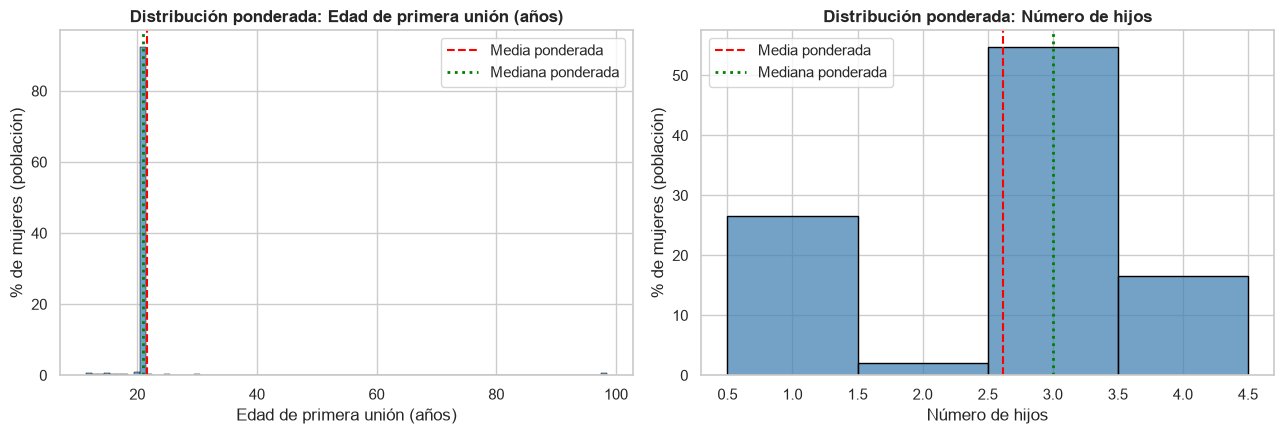

In [8]:
pdf = df_ok.select(VARS + [PESO]).to_pandas()
titulos = {"edad_primer_union": "Edad de primera unión (años)", "num_hijos": "Número de hijos"}

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, v in zip(ejes, VARS):
    sns.histplot(data=pdf, x=v, weights=PESO, discrete=True, stat="percent",
                 color="steelblue", edgecolor="black", ax=ax)
    ax.axvline(con_pond[v]["media_pond"], color="red", linestyle="--", label="Media ponderada")
    ax.axvline(con_pond[v]["mediana_pond"], color="green", linestyle=":", linewidth=2, label="Mediana ponderada")
    ax.set_title(f"Distribución ponderada: {titulos[v]}", fontweight="bold")
    ax.set_xlabel(titulos[v]); ax.set_ylabel("% de mujeres (población)")
    ax.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "01_histogramas_localizacion.png", dpi=150)
plt.show()

## Paso 8. Interpretación
- **Media vs. mediana:** la edad de primera unión tiene media de 21.61 y mediana de 21; el número de hijos, media de 2.61 y mediana de 3. En ambas variables las dos medidas están muy cerca.
- **Simple vs. ponderada:** ponderar casi no cambia nada (edad: 21.61 vs. 21.60; hijos: 2.61 vs. 2.61; las medianas son iguales). Aun así, la ponderada es la que describe a las mujeres del país y es la que se reporta.
- **Alerta importante:** el 92.2 % de las filas de `edad_primer_union` vale exactamente 21, y el 50.4 % de `num_hijos` vale exactamente 3. Es muy raro en datos reales y apunta a que una parte grande de estas columnas se rellenó con un solo valor al limpiar. Por eso el "perfil típico" de 21 años y 3 hijos refleja sobre todo esa imputación y no hay que tomarlo literal.
- **`nivel_escolaridad`:** la categoría más frecuente es a1. Sirve para describir el perfil más común, pero no dice qué tan distintas son las demás categorías.